# **Part 0 : Deliverable Guidelines**

The deliverable must consist of:
- One single `.ipynb` notebook (Python notebook)
- A PDF version exported from the notebook
- If possible, the dataset used should also be attached, or the data source should be clearly referenced in the notebook

https://huggingface.co/datasets/FinanceInc/auditor_sentiment

## **Timeline**

The final deliverable is expected **??**.



**Data Requirements**
The data must be taken from **Hugging Face**, and the topic must be related to:
- Finance
- Insurance
- Risk

## **Expectations**

You are expected to clearly explain the context and justify **why this use case is relevant**.

## **Why this problem?**


Explain:
- What the problem is
- Why it matters
- Why it is worth studying

## **What is the data?**

Explain:
- What the dataset is
- Why this dataset was chosen
- How the data is prepared
- Why the data is suitable for the problem

## **Supervised Model**


You must build a **supervised learning model** using the chosen data type, such as:
- Image
- Audio
- Text
- etc.

Minimum expected:
- Decision Tree  
**or**
- Random Forest

## **Study and Interpretation of Results ⭐ (Most Important)**


You are expected to analyze and interpret the model results:

- Is the model performance satisfactory?
- How can the results be interpreted?
- Why are the results good or bad?
- What could have been improved?
- What are the limitations of the results?
- Are there any constraints such as:
  - High model cost
  - Ethical risks
  - Bias
  - Practical limitations

## **Evaluation Criteria**

- **6 to 8 points** → Quality of explanations  
- **2 points** → Quality of code  
- **4 to 6 points** → Depth of the work  
- **6 to 8 points** → Respect of instructions and requirements  

# **Part 1 : Data Preperation**

## **1.1 - Import Data Set**

We first found and imported our auditor_sentiment data set from hungging face by connecting to our account with a token.

In [ ]:
from datasets import load_dataset
ds = load_dataset("Tydyannes69/auditor_sentiment")

Then we wanted to have a look at the data set to see if the importation functioned. So we decided to create a CSV file to be able to visulize it. The data base was already separated in two different data set. A "Train" and "Test" data set. We decided to keep it this way, so we could train our model on the "Train" data set and then measure the quality of our trained model on the "Test" data set.

In [ ]:
import pandas as pd

df = ds["train"].to_pandas()
df1 = ds["test"].to_pandas()

print(df.head())
print(df.columns)

df.to_csv("train.csv", index=False)
df1.to_csv("test.csv", index=False)

                                            sentence  label
0  Altia 's operating profit jumped to EUR 47 mil...      2
1  The agreement was signed with Biohit Healthcar...      2
2  Kesko pursues a strategy of healthy , focused ...      2
3  Vaisala , headquartered in Helsinki in Finland...      1
4  Also , a six-year historic analysis is provide...      1
Index(['sentence', 'label'], dtype='object')


## **1.2 - Descriptive Statistics**

Before doing any descriptive statistics we wanted to combine the "train" and "test" dataset to be able to study our entire dataset

In [ ]:
df_combined = pd.concat([df, df1], ignore_index=True)

In [ ]:
# Nombre de lignes et colonnes
num_rows = df_combined.shape[0]
num_cols = df_combined.shape[1]

print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print(f"Names of the Columns: {ds['train'].column_names}")

Number of rows: 4846
Number of columns: 2
Names of the Columns: ['sentence', 'label']


## Transformation of the variable "label"

In [ ]:
df_combined["label_num"] = df_combined["label"].map({
    0: "negative",
    1: "neutral",
    2: "positive"
})

## Description of the variable "label"

In [ ]:
print("Distribution des classes :")
print(df_combined["label_num"].value_counts())

print("\nProportions (%) :")
print((df_combined["label_num"].value_counts(normalize=True) * 100).round(2))

Distribution des classes :
label_num
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64

Proportions (%) :
label_num
neutral     59.41
positive    28.13
negative    12.46
Name: proportion, dtype: float64


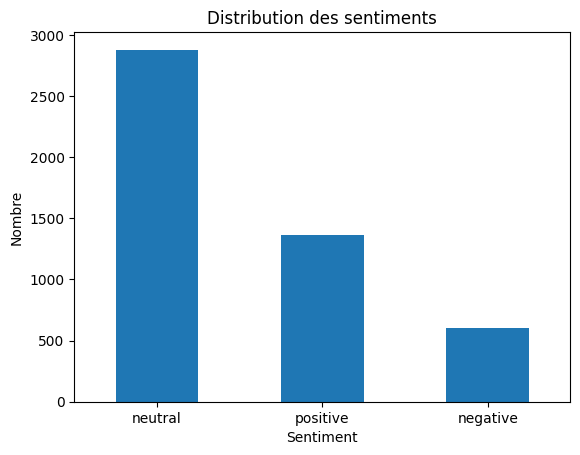

In [ ]:
import matplotlib.pyplot as plt

df_combined["label_num"].value_counts().plot(kind="bar")
plt.title("Distribution des sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Nombre")
plt.xticks(rotation=0)
plt.show()